<a href="https://colab.research.google.com/github/Mytros/DS_ML_homework/blob/main/HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2_Dmytro_Koval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [12]:
!pip install mlxtend

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.plotting import plot_decision_regions

from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
df = pd.read_csv("/content/drive/MyDrive/DS_ML/bank-customer-churn-prediction-dlu-course-c-3/train.csv")

In [16]:
!wget -O process_bank_churn.py https://raw.githubusercontent.com/Mytros/DS_ML_homework/main/process_bank_churn.py

--2025-07-28 20:56:45--  https://raw.githubusercontent.com/Mytros/DS_ML_homework/main/process_bank_churn.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4865 (4.8K) [text/plain]
Saving to: ‘process_bank_churn.py’

process_bank_churn. 100%[===================>]   4.75K  --.-KB/s    in 0s      

2025-07-28 20:56:45 (29.6 MB/s) - ‘process_bank_churn.py’ saved [4865/4865]



In [17]:
from process_bank_churn import preprocess_data

In [18]:
X_train, train_targets, X_val, val_targets, input_cols, scaler, encoder = preprocess_data(df, scaler_numeric=True)

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [19]:
knn = KNeighborsClassifier()
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [20]:
from sklearn.metrics import roc_auc_score

# predict proba
train_probs = knn.predict_proba(X_train)[:, 1]
val_probs = knn.predict_proba(X_val)[:, 1]

#  AUROC
train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

Train AUROC: 0.9600
Validation AUROC: 0.8642


Висновок: завелика різниця між тренуванням і валідацією свідчить про high variance або перенавчання.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [21]:
knn = KNeighborsClassifier()
params_knn = {'n_neighbors': np.arange(1, 25)}
knn_gs = GridSearchCV(knn, params_knn, cv=5)
knn_gs.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])})

In [22]:
knn_best = knn_gs.best_estimator_

print(knn_gs.best_params_, knn_gs.best_score_)

{'n_neighbors': np.int64(13)} 0.8816666666666666


In [23]:
from sklearn.metrics import roc_auc_score

# predict proba
train_probs_best = knn_best.predict_proba(X_train)[:, 1]
val_probs_best = knn_best.predict_proba(X_val)[:, 1]

# AUROC
train_auc_best = roc_auc_score(train_targets, train_probs_best)
val_auc_best = roc_auc_score(val_targets, val_probs_best)

print(f"Train AUROC (best): {train_auc_best:.4f}")
print(f"Validation AUROC (best): {val_auc_best:.4f}")


Train AUROC (best): 0.9418
Validation AUROC (best): 0.8990


In [24]:
def get_report(model, X_test, y_true):
    y_pred = model.predict(X_test)
    print(classification_report(y_true, y_pred, digits=4))

get_report(knn_best, X_train, train_targets)

              precision    recall  f1-score   support

         0.0     0.9093    0.9670    0.9373      9558
         1.0     0.8283    0.6224    0.7108      2442

    accuracy                         0.8969     12000
   macro avg     0.8688    0.7947    0.8240     12000
weighted avg     0.8928    0.8969    0.8912     12000



Висновок:

Показники дерева рішень:

Train AUROC 0.9201

Validation: 0.9193

Обидві моделі показали хороші результати. Але з точки зору валідаційної AUROC, то дерево прийняття рішень є трохи кращим вибором у цьому конкретному випадку. Воно є більш "сбалансованим", так як менша різниця між тренуванням і валідацією.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
# params
param_grid = {
    'max_depth': list(range(1, 21, 2)),
    'max_leaf_nodes': list(range(2, 11, 1))
}

# DT Classifier
dt = DecisionTreeClassifier(random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# time
%time
grid_search.fit(X_train, train_targets)





CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.96 µs
Fitting 3 folds for each of 90 candidates, totalling 270 fits


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
                         'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='roc_auc', verbose=1)

In [27]:
# best hyperparams
print("best params:", grid_search.best_params_)
dt_best = grid_search.best_estimator_
# predict proba
train_probs_dt = dt_best.predict_proba(X_train)[:, 1]
val_probs_dt = dt_best.predict_proba(X_val)[:, 1]

# AUROC
train_auc_dt = roc_auc_score(train_targets, train_probs_dt)
val_auc_dt = roc_auc_score(val_targets, val_probs_dt)

print(f"Train AUROC (best tree): {train_auc_dt:.4f}")
print(f"Validation AUROC (best tree): {val_auc_dt:.4f}")


best params: {'max_depth': 5, 'max_leaf_nodes': 10}
Train AUROC (best tree): 0.9015
Validation AUROC (best tree): 0.9002


In [28]:
get_report(dt_best, X_train, train_targets)

              precision    recall  f1-score   support

         0.0     0.8986    0.9643    0.9303      9558
         1.0     0.8044    0.5741    0.6700      2442

    accuracy                         0.8849     12000
   macro avg     0.8515    0.7692    0.8002     12000
weighted avg     0.8794    0.8849    0.8773     12000



Висновок:

Train/Val AUROC майже однакові — модель не переобучена, дуже добре узагальнює.

Validation AUROC трохи нижча, ніж у дерева з завдання 2.3 (0.9002 vs 0.9193).

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [29]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import time

In [30]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [31]:
from sklearn.model_selection import StratifiedKFold

dt = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=params_dt,
    n_iter=40,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)
%time
start_time = time.time()
random_search.fit(X_train, train_targets)
end_time = time.time()
print(f"Time RandomizedSearchCV: {end_time - start_time:.2f} seconds")


CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 9.3 µs
Fitting 3 folds for each of 40 candidates, totalling 120 fits
Time RandomizedSearchCV: 1.80 seconds


In [32]:
print("Best params:", random_search.best_params_)
dt_random_search_best = random_search.best_estimator_


Best params: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}


In [33]:
train_probs_rand = dt_random_search_best.predict_proba(X_train)[:, 1]
val_probs_rand = dt_random_search_best.predict_proba(X_val)[:, 1]

train_auc_rand = roc_auc_score(train_targets, train_probs_rand)
val_auc_rand = roc_auc_score(val_targets, val_probs_rand)

print(f"Train AUROC (random search): {train_auc_rand:.4f}")
print(f"Validation AUROC (random search): {val_auc_rand:.4f}")


Train AUROC (random search): 0.9169
Validation AUROC (random search): 0.9166


Висновок:

Найкращі параметри:

    {'splitter': 'best',
    'min_samples_split': 20,
    'min_samples_leaf': 2,
    'max_leaf_nodes': np.int64(14),
    'max_features': None,
    'max_depth': np.int64(16),
    'criterion': 'entropy'}

Validation AUROC = 0.9166 -  найкращий результат серед усіх моделей.


Модель складніша, але добре контрольована, немає overfitting.

У порівнянні з GridSearch, вона використовує потенціал дерева повніше.  

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [34]:
import pandas as pd
from process_bank_churn import preprocess_new_data

test_df = pd.read_csv("/content/drive/MyDrive/DS_ML/bank-customer-churn-prediction-dlu-course-c-3/test.csv")
sample_sub = pd.read_csv("/content/drive/MyDrive/DS_ML/bank-customer-churn-prediction-dlu-course-c-3/sample_submission.csv")

# preprocessing
X_test_processed = preprocess_new_data(
    df=test_df,
    input_cols=input_cols,
    encoder=encoder,
    scaler=scaler
)

# predict_proba
test_probs = dt_random_search_best.predict_proba(X_test_processed)[:, 1]

# write submission
submission = pd.DataFrame({
    "id": sample_sub["id"],
    "Exited": test_probs
})

# save submission
submission.to_csv("/content/drive/MyDrive/DS_ML/submissions/submission_knn.csv", index=False)




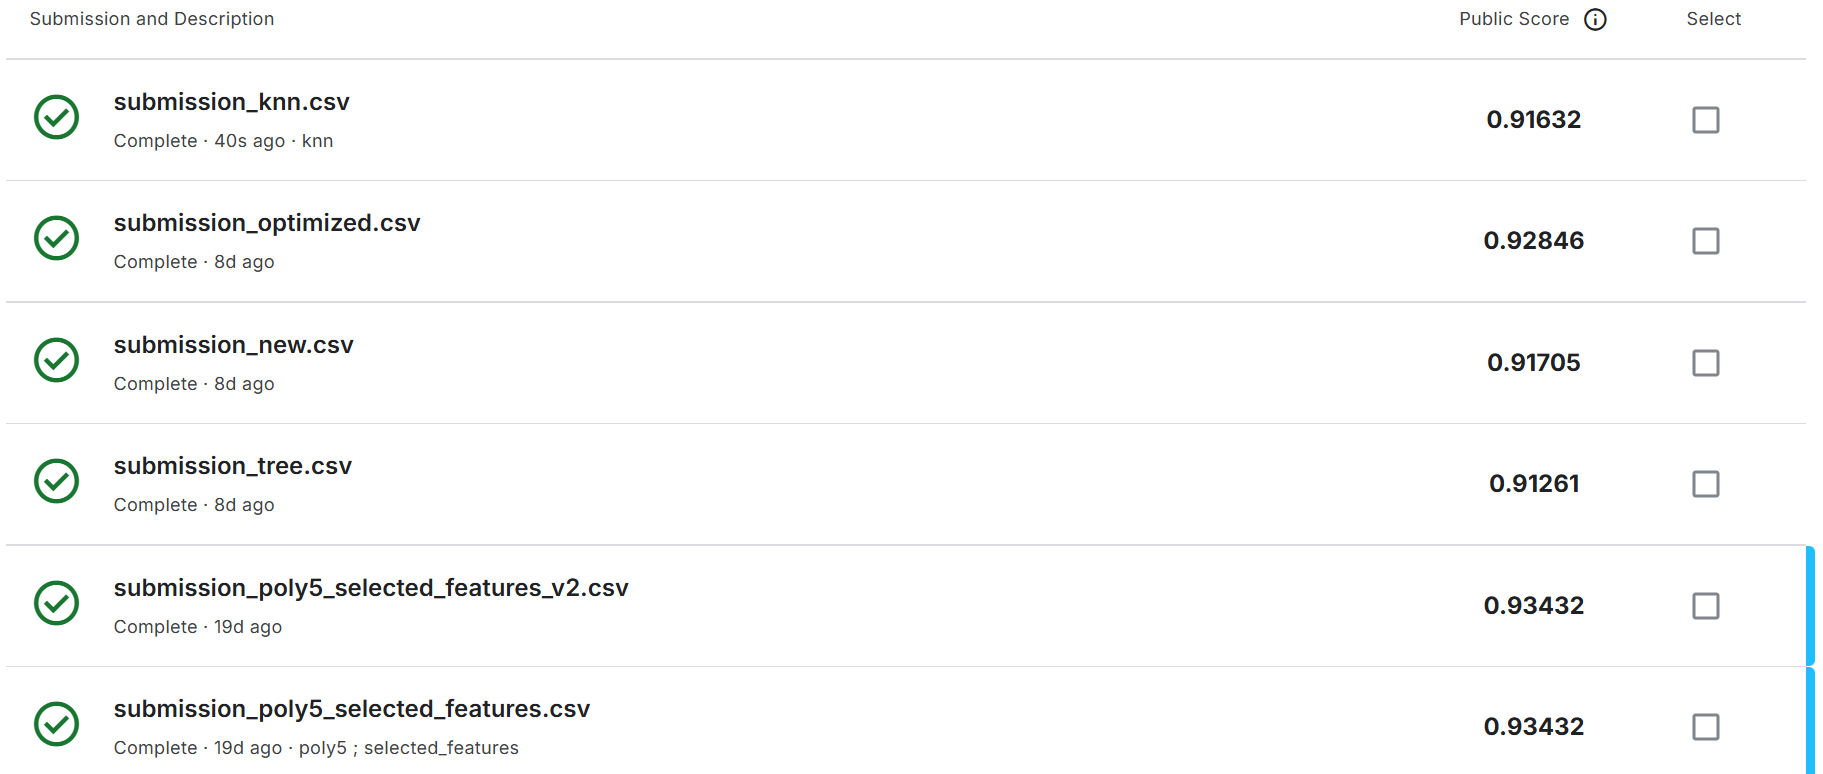